# Ćwiczenie 6 — Analiza sygnału za pomocą baz wielomianowych

## Zadanie

Do tej pory poznaliśmy głównie bazę wielomianową. Wielomiany nie są zbyt użytecznymi funkcjami do analizy rzeczywistych sygnałów (nie oddają dobrze ich właściwości), ale idea wykorzystania interpolacji/aproksymacji do analizy sygnału może zostać dobrze pokazana na tym przykładzie, o ile funkcją oryginalną będzie wielomian.

Poniższy kod wykonuje dopasowanie wielomianowe -- bazą są funkcje $1, x, x^2, \ldots, x^{M-1}$, gdzie $M$ to długość bazy (liczba funkcji) -- i wypisuje współczynniki tego dopasowania. Każdy współczynnik $p_i$ mówi, ile funkcji bazowej $x^{M-i}$ jest „obecne” w sygnale -- to właśnie **współczynniki korelacji** tego ćwiczenia: duży współczynnik oznacza silną korelację/podobieństwo do danej funkcji bazowej, mały (bliski zeru) oznacza, że tej funkcji w sygnale nie ma. To dokładnie ta sama idea co współczynniki DFT w rozdziale o transformacie Fouriera (tam bazą są sin/cos różnych częstotliwości zamiast potęg $x$).

**UWAGA!** W przypadku podania zbyt długiej bazy (więcej funkcji bazowych niż punktów danych) zastosowany zostanie *padding* -- dopełnienie brakujących punktów zerami na końcu szeregu. Dla analizy wielomianowej nie jest to w żaden sposób pomocne (psuje interpretację współczynników), ale chodzi o oswojenie się z tą techniką.

**Ćwiczenie:**

Korzystając z poniższego kodu spróbuj przeanalizować różne funkcje oryginalne przy różnych konfiguracjach danych wejściowych i długości bazy. Zobacz, kiedy uzyskujesz sensowne wyniki (przydatne informacje), a kiedy nie.

- Wypróbuj funkcje oryginalne, które są wielomianami, i takie, które nie są.
- Spróbuj ustawić długość bazy na większą niż liczba punktów i na mniejszą.
- Spróbuj ustawić długość bazy tak, żeby zabrakło w niej największej składowej wielomianu oryginalnego.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def do_stuff(xw, no_of_functions, fun):
    """Dopasowuje wielomian o bazie {1, x, x^2, ..., x^(no_of_functions-1)}
    do danych fun(xw) i wypisuje wspolczynniki dopasowania do kazdej funkcji
    bazowej (patrz komorka opisowa wyzej -- to sa "wspolczynniki korelacji"
    tego cwiczenia). Odtwarza mechanizm MATLAB-owej funkcji doStuff.
    """
    xw = np.asarray(xw, dtype=float)
    n = len(xw)

    if no_of_functions > n:
        # Za dluga baza -- dopelniamy PADDINGIEM: dodajemy brakujace punkty
        # x (w tym samym odstepie co reszta danych) z wartoscia y=0. To NIE
        # jest prawdziwa proba fun() w tych punktach, tylko sztuczne
        # wypelnienie zerami -- psuje interpretacje wspolczynnikow, ale
        # pozwala kodowi zadzialac dla dowolnej dlugosci bazy.
        h = np.mean(np.diff(xw))
        extra_x = xw[-1] + h * np.arange(1, no_of_functions - n + 1)
        yw = np.concatenate([fun(xw), np.zeros(no_of_functions - n)])
        xw_full = np.concatenate([xw, extra_x])
    elif no_of_functions < n:
        # Za krotka baza -- uzywamy tylko pierwszych no_of_functions punktow
        xw_full = xw[:no_of_functions]
        yw = fun(xw_full)
    else:
        # Baza dokladnie tej samej dlugosci co liczba punktow -- dopasowanie
        # jest DOKLADNE (interpolacja), wiec wspolczynniki pokazuja wprost,
        # ktore potegi x sa obecne w sygnale
        xw_full = xw
        yw = fun(xw_full)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xw_full, yw, 'ok', markersize=8, label='dane (po ew. paddingu/obcięciu)')

    xx = np.linspace(xw_full.min(), xw_full.max(), 400)
    yy = fun(xx)
    ax.plot(xx, yy, '--', color=[0.7, 0.7, 0.7], label='funkcja oryginalna')

    # polyfit zwraca wspolczynniki od najwyzszej potegi do stalej -- tak
    # samo jak MATLAB-owy polyfit -- wiec p1 to wspolczynnik przy
    # najwyzszej potedze x, a ostatni (p_no_of_functions) to wyraz wolny
    coeffs = np.polyfit(xw_full, yw, no_of_functions - 1)
    for i, c in enumerate(coeffs, start=1):
        print(f"Współczynnik p{i} = {c:0.2e}")

    ax.plot(xx, np.polyval(coeffs, xx), 'g-.', linewidth=2, label='dopasowany wielomian')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return coeffs

Współczynnik p1 = -1.08e+01
Współczynnik p2 = 1.63e+02
Współczynnik p3 = -9.19e+02
Współczynnik p4 = 2.43e+03
Współczynnik p5 = -2.96e+03
Współczynnik p6 = 1.30e+03


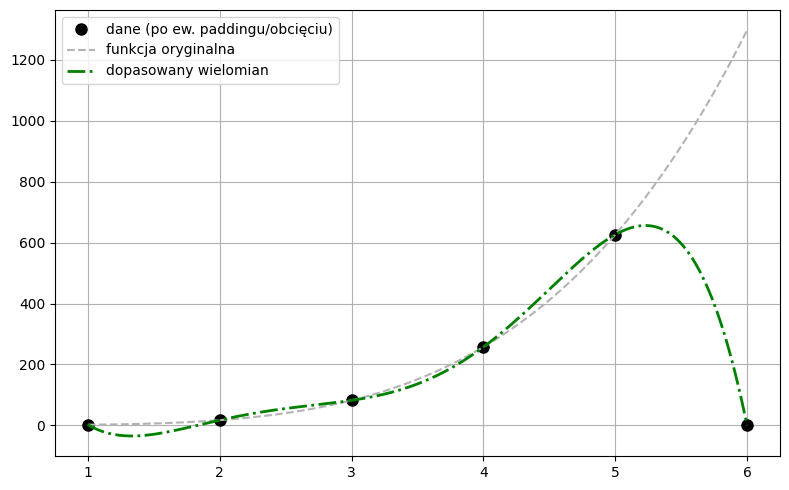

In [3]:
# Funkcja oryginalna
f = lambda x: x**4 + 1

# Położenia węzłów
xw = np.array([1, 2, 3, 4, 5])

# Ilość funkcji z bazy
no_of_functions = 6

do_stuff(xw, no_of_functions, f);

### Co się stanie, gdy długość bazy dokładnie odpowiada liczbie punktów?

Powyższy przykład (6 funkcji bazowych, 5 punktów) demonstruje padding -- zgodnie z UWAGĄ wyżej, wynikowe współczynniki nic nie mówią o oryginalnej funkcji. Sprawdźmy teraz przypadek `no_of_functions = 5` (dokładnie tyle, ile mamy punktów) -- to jeden z eksperymentów, o które prosi Ćwiczenie powyżej.

Współczynnik p1 = 1.00e+00
Współczynnik p2 = 1.24e-13
Współczynnik p3 = -5.80e-13
Współczynnik p4 = 1.17e-12
Współczynnik p5 = 1.00e+00


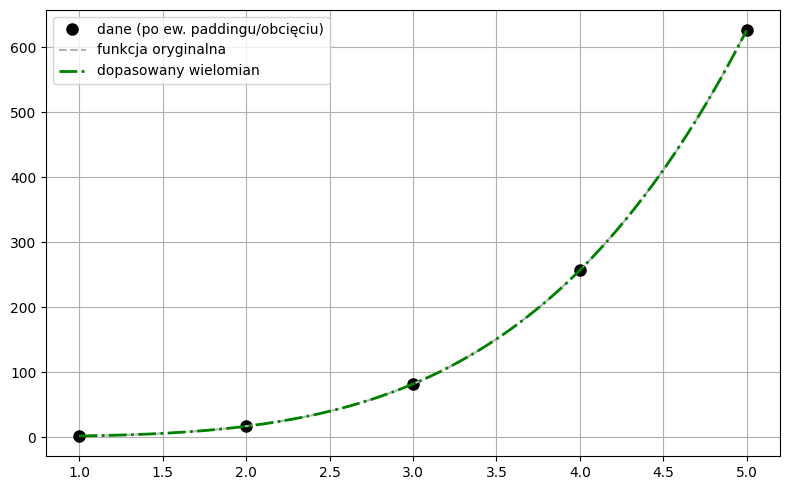

In [4]:
do_stuff(xw, 5, f);
# Współczynnik p1 (przy x^4) wychodzi ~1, p5 (wyraz wolny) ~1, reszta ~0 --
# dokładnie odtwarza definicję f(x) = x^4 + 1. Współczynniki DOSŁOWNIE
# pokazują, które potęgi x są "obecne" (skorelowane) z sygnałem.

## Podsumowanie

Współczynniki dopasowania do bazy wielomianowej pokazują, ile danej funkcji bazowej jest obecne w sygnale -- ale tylko wtedy, gdy dopasowanie jest dokładne (baza tej samej długości co liczba punktów) i funkcja oryginalna faktycznie jest wielomianem tego samego lub niższego stopnia. Gdy baza jest za długa (padding) lub za krótka (obcięcie punktów), współczynniki przestają mieć czytelną interpretację -- w praktyce (dla sygnałów, które NIE są wielomianami) używa się do tego celu innych baz (np. trygonometrycznej -- patrz DFT), które lepiej oddają rzeczywiste właściwości sygnałów.